In [10]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

PROJECT_ROOT = Path(r"D:\asif\customer-churn-prediction")

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
IMAGE_DIR = PROJECT_ROOT / "images"
APP_DIR = PROJECT_ROOT / "app"

DATA_PATH = DATA_DIR / "Telco-Customer-Churn.csv"
MODEL_PATH = MODEL_DIR / "churn_model.pkl"

DATA_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
IMAGE_DIR.mkdir(exist_ok=True)
APP_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: D:\asif\customer-churn-prediction
Dataset path: D:\asif\customer-churn-prediction\data\Telco-Customer-Churn.csv
Dataset exists: True


In [11]:
df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df_raw.shape)

df_raw.head()

Dataset loaded successfully
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
print("Columns:")
print(df_raw.columns.tolist())

print("\nDataset Info:")
df_raw.info()

print("\nMissing Values:")
print(df_raw.isnull().sum())

print("\nChurn Counts:")
print(df_raw["Churn"].value_counts())

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 

In [13]:
def clean_data(df):
    df = df.copy()

    df.columns = df.columns.str.strip()

    if "TotalCharges" in df.columns:
        df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
        df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

    if "SeniorCitizen" in df.columns:
        df["SeniorCitizen"] = df["SeniorCitizen"].replace({
            0: "No",
            1: "Yes",
            "0": "No",
            "1": "Yes"
        })

    if "Churn" in df.columns:
        df["Churn"] = df["Churn"].replace({
            "Yes": 1,
            "No": 0
        })

    if "customerID" in df.columns:
        df = df.drop(columns=["customerID"])

    return df


df = clean_data(df_raw)

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [14]:
def add_features(df):
    df = df.copy()

    if "tenure" in df.columns:
        df["TenureGroup"] = pd.cut(
            df["tenure"],
            bins=[-1, 12, 24, 48, 72, 10000],
            labels=["0-1 year", "1-2 years", "2-4 years", "4-6 years", "6+ years"]
        )

    service_columns = [
        "PhoneService",
        "MultipleLines",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ]

    existing_service_columns = [col for col in service_columns if col in df.columns]

    df["ServiceCount"] = 0

    for col in existing_service_columns:
        df["ServiceCount"] += (df[col].astype(str) == "Yes").astype(int)

    if "TechSupport" in df.columns:
        df["HasTechSupport"] = (df["TechSupport"].astype(str) == "Yes").astype(int)

    if "OnlineSecurity" in df.columns:
        df["HasOnlineSecurity"] = (df["OnlineSecurity"].astype(str) == "Yes").astype(int)

    if "PaymentMethod" in df.columns:
        df["AutoPayment"] = df["PaymentMethod"].isin([
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ]).astype(int)

    if "TotalCharges" in df.columns and "tenure" in df.columns and "MonthlyCharges" in df.columns:
        safe_tenure = df["tenure"].replace(0, np.nan)
        df["AvgChargesPerMonth"] = df["TotalCharges"] / safe_tenure
        df["AvgChargesPerMonth"] = df["AvgChargesPerMonth"].fillna(df["MonthlyCharges"])

    return df


df = add_features(df)

print("Dataset after feature engineering:", df.shape)
df.head()

Dataset after feature engineering: (7043, 26)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ServiceCount,HasTechSupport,HasOnlineSecurity,AutoPayment,AvgChargesPerMonth
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,Electronic check,29.85,29.85,0,0-1 year,1,0,0,0,29.850000
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,Mailed check,56.95,1889.50,0,2-4 years,3,0,1,0,55.573529
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,1,0-1 year,3,0,1,0,54.075000
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Bank transfer (automatic),42.30,1840.75,0,2-4 years,3,1,1,1,40.905556
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,1,0-1 year,1,0,0,0,75.825000


In [15]:
print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Percentage:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


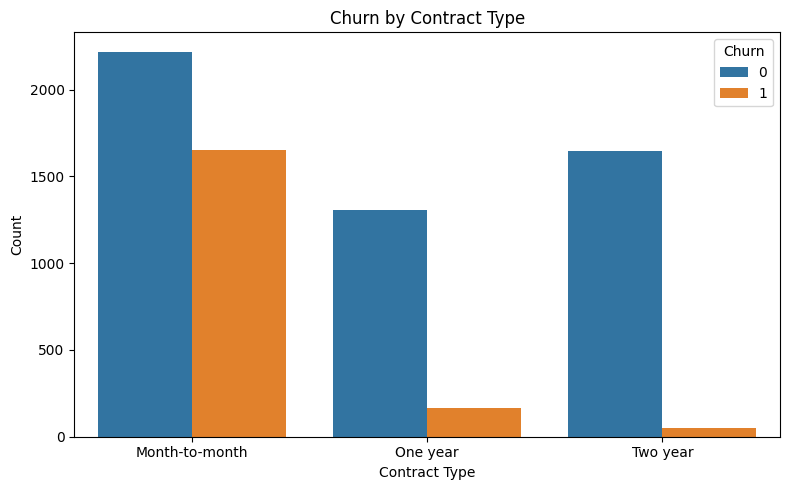

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "churn_by_contract.png", dpi=300)
plt.show()

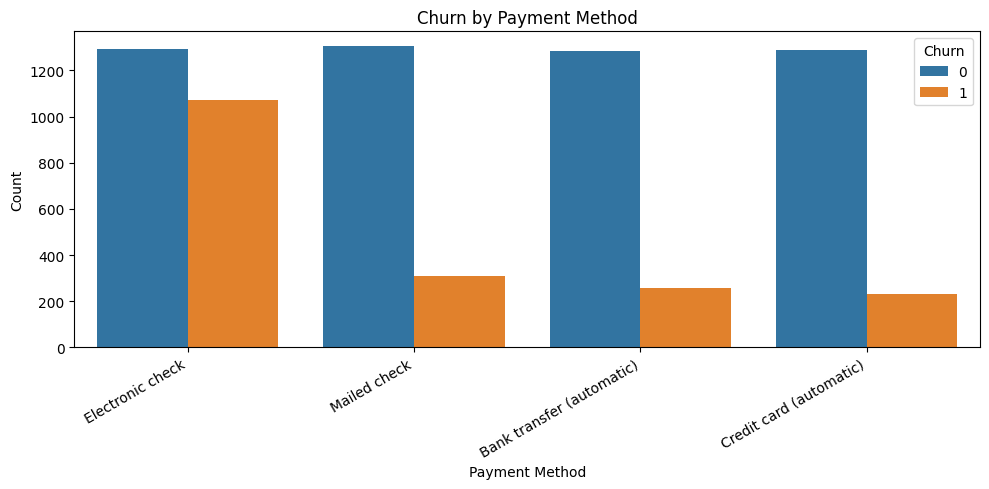

In [17]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "churn_by_payment_method.png", dpi=300)
plt.show()

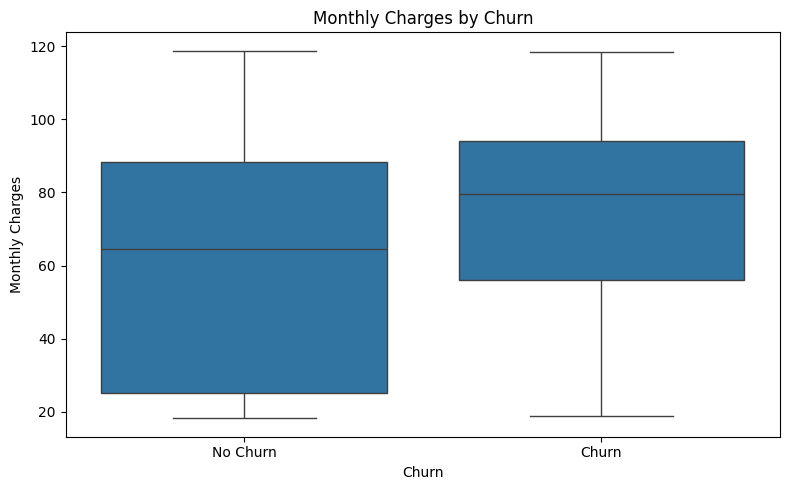

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.tight_layout()
plt.savefig(IMAGE_DIR / "monthly_charges_by_churn.png", dpi=300)
plt.show()

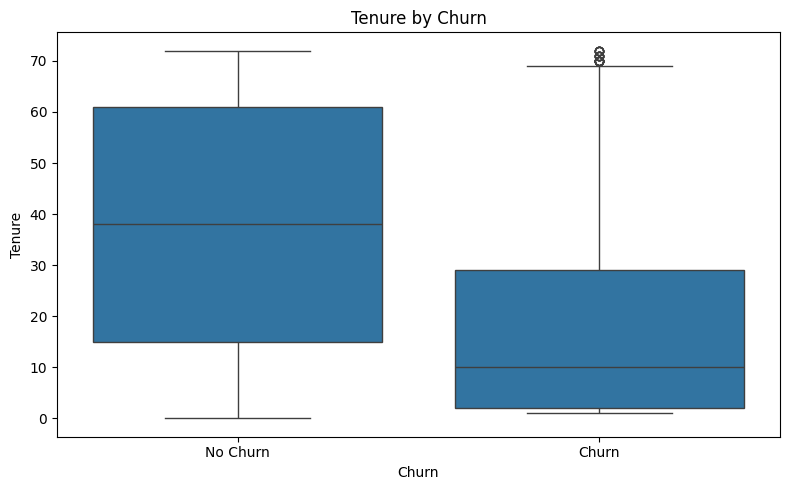

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.tight_layout()
plt.savefig(IMAGE_DIR / "tenure_by_churn.png", dpi=300)
plt.show()

In [20]:
X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

feature_columns = X.columns.tolist()

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_columns = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumeric columns:")
print(numeric_columns)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Categorical columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Numeric columns:
['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'HasTechSupport', 'HasOnlineSecurity', 'AutoPayment', 'AvgChargesPerMonth']
Training shape: (5634, 25)
Testing shape: (1409, 25)


In [21]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

try:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", categorical_encoder)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully")

Preprocessing pipeline created successfully


In [22]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    )
}

trained_models = {}

for model_name, model in models.items():
    print("Training:", model_name)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline

print("Models trained successfully")

Training: Logistic Regression
Training: Random Forest
Models trained successfully


In [23]:
def evaluate_model(model_name, model, X_test, y_test, threshold=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }


results = []

for model_name, model in trained_models.items():
    results.append(evaluate_model(model_name, model, X_test, y_test))

metrics_df = pd.DataFrame(results)
metrics_df = metrics_df.sort_values(by=["F1 Score", "Recall", "ROC AUC"], ascending=False)

metrics_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Random Forest,0.772889,0.556485,0.711230,0.624413,0.839225
0,Logistic Regression,0.733144,0.498316,0.791444,0.611570,0.841879


In [24]:
for model_name, model in trained_models.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1035
           1       0.56      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [25]:
best_model_name = metrics_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


In [26]:
thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

y_proba = best_model.predict_proba(X_test)[:, 1]

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.20,0.420925,0.925134,0.578595
1,0.25,0.445767,0.901070,0.596460
2,0.30,0.472222,0.863636,0.610586
3,0.35,0.504065,0.828877,0.626896
4,0.40,0.517668,0.783422,0.623404
5,0.45,0.532567,0.743316,0.620536
6,0.50,0.556485,0.711230,0.624413
7,0.55,0.560465,0.644385,0.599502
8,0.60,0.598916,0.590909,0.594886
9,0.65,0.651757,0.545455,0.593886


In [27]:
best_threshold_row = threshold_df.sort_values(
    by=["F1 Score", "Recall"],
    ascending=False
).iloc[0]

best_threshold = float(best_threshold_row["Threshold"])

print("Best threshold:", best_threshold)
best_threshold_row

Best threshold: 0.35


Threshold    0.350000
Precision    0.504065
Recall       0.828877
F1 Score     0.626896
Name: 3, dtype: float64

In [28]:
final_y_proba = best_model.predict_proba(X_test)[:, 1]
final_y_pred = (final_y_proba >= best_threshold).astype(int)

print("Final Model:", best_model_name)
print("Best Threshold:", best_threshold)

print("\nClassification Report:")
print(classification_report(y_test, final_y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_y_pred))

Final Model: Random Forest
Best Threshold: 0.35

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1035
           1       0.50      0.83      0.63       374

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.74      0.75      1409


Confusion Matrix:
[[730 305]
 [ 64 310]]


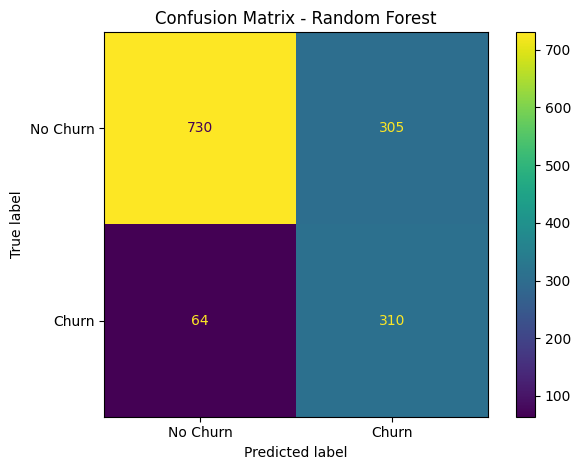

In [29]:
cm = confusion_matrix(y_test, final_y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

display.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "confusion_matrix.png", dpi=300)
plt.show()

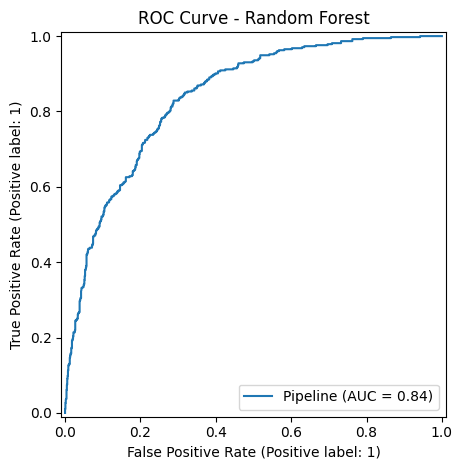

In [30]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"ROC Curve - {best_model_name}")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "roc_curve.png", dpi=300)
plt.show()

In [31]:
model_artifact = {
    "model": best_model,
    "model_name": best_model_name,
    "threshold": best_threshold,
    "feature_columns": feature_columns,
    "categorical_columns": categorical_columns,
    "numeric_columns": numeric_columns
}

joblib.dump(model_artifact, MODEL_PATH)

metrics_df.to_csv(PROJECT_ROOT / "model_metrics.csv", index=False)
threshold_df.to_csv(PROJECT_ROOT / "threshold_results.csv", index=False)

print("Model saved at:", MODEL_PATH)
print("Metrics saved at:", PROJECT_ROOT / "model_metrics.csv")
print("Threshold results saved at:", PROJECT_ROOT / "threshold_results.csv")

Model saved at: D:\asif\customer-churn-prediction\models\churn_model.pkl
Metrics saved at: D:\asif\customer-churn-prediction\model_metrics.csv
Threshold results saved at: D:\asif\customer-churn-prediction\threshold_results.csv


In [32]:
sample_customer = X_test.iloc[[0]]

loaded_artifact = joblib.load(MODEL_PATH)

loaded_model = loaded_artifact["model"]
loaded_threshold = loaded_artifact["threshold"]

sample_probability = loaded_model.predict_proba(sample_customer)[:, 1][0]
sample_prediction = int(sample_probability >= loaded_threshold)

print("Churn probability:", round(sample_probability, 4))
print("Prediction:", "Churn" if sample_prediction == 1 else "No Churn")

sample_customer

Churn probability: 0.017
Prediction: No Churn


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup,ServiceCount,HasTechSupport,HasOnlineSecurity,AutoPayment,AvgChargesPerMonth
437,Male,No,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Credit card (automatic),114.05,8468.2,4-6 years,8,1,1,1,117.613889
